# Step 4 & 5: Model Development & Evaluation
**Project:** Taobao CTR Prediction — Big Data Pipeline  
**Models:** Logistic Regression | Random Forest | Gradient Boosted Trees  
**Target:** `clk` (1 = clicked, 0 = not clicked)

## Cell 0 — HADOOP Setup

In [1]:
import os

os.environ["HADOOP_HOME"]     = "D:\\Apps\\hadoop"
os.environ["hadoop.home.dir"] = "D:\\Apps\\hadoop"
os.environ["PATH"]            = "D:\\Apps\\hadoop\\bin;" + os.environ["PATH"]

print(" HADOOP_HOME:", os.environ["HADOOP_HOME"])
print(" Hadoop configured!")

 HADOOP_HOME: D:\Apps\hadoop
 Hadoop configured!


## Cell 1 — Spark Session & Imports

In [2]:
import findspark
findspark.init()

import os
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

OUTPUT_PATH = "D:/Apps/ProjectBigData/"
TRAIN_PATH  = OUTPUT_PATH + "processed_data/train"
TEST_PATH   = OUTPUT_PATH + "processed_data/test"
MODEL_PATH  = OUTPUT_PATH + "models/"
CHARTS_PATH = OUTPUT_PATH + "charts/"

os.makedirs(MODEL_PATH,  exist_ok=True)
os.makedirs(CHARTS_PATH, exist_ok=True)

spark = SparkSession.builder \
    .appName("Taobao_CTR_Modeling") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.network.timeout", "800s") \
    .config("spark.executor.heartbeatInterval", "60s") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(" Spark Version:", spark.version)
print(" Spark Session Started!")

 Spark Version: 4.1.1
 Spark Session Started!


## Cell 2 — Load Processed Data

In [3]:
print(" Loading processed data...\n")

train_df = spark.read.parquet(TRAIN_PATH)
test_df  = spark.read.parquet(TEST_PATH)


train_df = train_df.sample(fraction=0.5, seed=42)
test_df  = test_df.sample(fraction=0.5, seed=42)

train_count = train_df.count()
test_count  = test_df.count()

print(f" Train records (10% sample) : {train_count:,}")
print(f" Test  records (10% sample) : {test_count:,}")

train_df.cache()
test_df.cache()

print("\n Data loaded & cached!")

 Loading processed data...

 Train records (10% sample) : 11,622,611
 Test  records (10% sample) : 1,655,625

 Data loaded & cached!


## Cell 3 — Helper: Evaluation Function

In [4]:
def evaluate_model(predictions, model_name):
    binary_eval = BinaryClassificationEvaluator(
        labelCol="clk",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )
    multi_eval = MulticlassClassificationEvaluator(
        labelCol="clk",
        predictionCol="prediction"
    )

    auc       = binary_eval.evaluate(predictions)
    accuracy  = multi_eval.setMetricName("accuracy").evaluate(predictions)
    precision = multi_eval.setMetricName("weightedPrecision").evaluate(predictions)
    recall    = multi_eval.setMetricName("weightedRecall").evaluate(predictions)
    f1        = multi_eval.setMetricName("f1").evaluate(predictions)

    results = {
        "Model"    : model_name,
        "AUC-ROC"  : round(auc,       4),
        "Accuracy" : round(accuracy,  4),
        "Precision": round(precision, 4),
        "Recall"   : round(recall,    4),
        "F1-Score" : round(f1,        4)
    }

    print(f"\n   {model_name} Results:")
    print(f"     AUC-ROC   : {auc:.4f}")
    print(f"     Accuracy  : {accuracy:.4f}")
    print(f"     Precision : {precision:.4f}")
    print(f"     Recall    : {recall:.4f}")
    print(f"     F1-Score  : {f1:.4f}")

    return results

all_results = []
print(" Evaluation function ready!")

 Evaluation function ready!


## Cell 4 — Model 1: Logistic Regression

In [5]:
print(" MODEL 1: LOGISTIC REGRESSION")
print("=" * 50)

start = time.time()

lr = LogisticRegression(
    featuresCol="features",
    labelCol="clk",
    weightCol="class_weight",
    maxIter=10,
    regParam=0.01
)

print(" Training Logistic Regression...")
lr_model       = lr.fit(train_df)
lr_predictions = lr_model.transform(test_df)

elapsed = round(time.time() - start, 2)
print(f"   Training done in {elapsed}s")

lr_results = evaluate_model(lr_predictions, "Logistic Regression")
all_results.append(lr_results)

lr_model.write().overwrite().save(MODEL_PATH + "logistic_regression")
print(f"\n   Model saved → {MODEL_PATH}logistic_regression")
print("\n Logistic Regression complete!")

 MODEL 1: LOGISTIC REGRESSION
 Training Logistic Regression...
   Training done in 30.26s

   Logistic Regression Results:
     AUC-ROC   : 0.8257
     Accuracy  : 0.7771
     Precision : 0.9371
     Recall    : 0.7771
     F1-Score  : 0.8375

   Model saved → D:/Apps/ProjectBigData/models/logistic_regression

 Logistic Regression complete!


## Cell 5 — Model 2: Random Forest

In [6]:
print(" MODEL 2: RANDOM FOREST")
print("=" * 50)

start = time.time()

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="clk",
    weightCol="class_weight",
    numTrees=100,
    maxDepth=8,
    seed=42
)

print(" Training Random Forest (100 trees)...")
rf_model       = rf.fit(train_df)
rf_predictions = rf_model.transform(test_df)

elapsed = round(time.time() - start, 2)
print(f"   Training done in {elapsed}s")

rf_results = evaluate_model(rf_predictions, "Random Forest")
all_results.append(rf_results)

# Feature Importance
print("\n   Top 10 Feature Importances:")
importances = rf_model.featureImportances.toArray()
top10_idx   = importances.argsort()[-10:][::-1]
for i, idx in enumerate(top10_idx):
    print(f"     {i+1}. Feature[{idx}]: {importances[idx]:.4f}")

# Save model
rf_model.write().overwrite().save(MODEL_PATH + "random_forest")
print(f"\n   Model saved → {MODEL_PATH}random_forest")
print("\n Random Forest complete!")

🤖 MODEL 2: RANDOM FOREST
 Training Random Forest (100 trees)...
   Training done in 420.56s

   Random Forest Results:
     AUC-ROC   : 0.8342
     Accuracy  : 0.6717
     Precision : 0.9429
     Recall    : 0.6717
     F1-Score  : 0.7634

   Top 10 Feature Importances:
     1. Feature[16]: 0.5307
     2. Feature[6]: 0.2320
     3. Feature[15]: 0.2156
     4. Feature[7]: 0.0158
     5. Feature[4]: 0.0019
     6. Feature[0]: 0.0015
     7. Feature[3]: 0.0013
     8. Feature[13]: 0.0003
     9. Feature[1]: 0.0002
     10. Feature[9]: 0.0002

   Model saved → D:/Apps/ProjectBigData/models/random_forest

 Random Forest complete!


## Cell 6 — Model 3: Gradient Boosted Trees

In [7]:
print(" MODEL 3: GRADIENT BOOSTED TREES (GBT)")
print("=" * 50)

start = time.time()

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="clk",
    weightCol="class_weight",
    maxIter=20,
    maxDepth=5,
    seed=42
)

print(" Training GBT (maxIter=20)...")
gbt_model       = gbt.fit(train_df)
gbt_predictions = gbt_model.transform(test_df)

elapsed = round(time.time() - start, 2)
print(f"   Training done in {elapsed}s")

gbt_results = evaluate_model(gbt_predictions, "GBT")
all_results.append(gbt_results)

# Feature Importance
print("\n   Top 10 Feature Importances:")
importances = gbt_model.featureImportances.toArray()
top10_idx   = importances.argsort()[-10:][::-1]
for i, idx in enumerate(top10_idx):
    print(f"     {i+1}. Feature[{idx}]: {importances[idx]:.4f}")

# Save model
gbt_model.write().overwrite().save(MODEL_PATH + "gbt")
print(f"\n   Model saved → {MODEL_PATH}gbt")
print("\n GBT complete!")

 MODEL 3: GRADIENT BOOSTED TREES (GBT)
 Training GBT (maxIter=20)...
   Training done in 110.48s

   GBT Results:
     AUC-ROC   : 0.8401
     Accuracy  : 0.7061
     Precision : 0.9418
     Recall    : 0.7061
     F1-Score  : 0.7887

   Top 10 Feature Importances:
     1. Feature[16]: 0.6742
     2. Feature[6]: 0.3031
     3. Feature[7]: 0.0204
     4. Feature[15]: 0.0011
     5. Feature[9]: 0.0006
     6. Feature[0]: 0.0002
     7. Feature[4]: 0.0001
     8. Feature[1]: 0.0001
     9. Feature[5]: 0.0001
     10. Feature[2]: 0.0000

   Model saved → D:/Apps/ProjectBigData/models/gbt

 GBT complete!


## Cell 7 — Models Comparison Table

 MODELS COMPARISON

                      AUC-ROC  Accuracy  Precision  Recall  F1-Score
Model                                                              
Logistic Regression   0.8257    0.7771     0.9371  0.7771    0.8375
Random Forest         0.8342    0.6717     0.9429  0.6717    0.7634
GBT                   0.8401    0.7061     0.9418  0.7061    0.7887

   Best Model : GBT
     AUC-ROC    : 0.8401


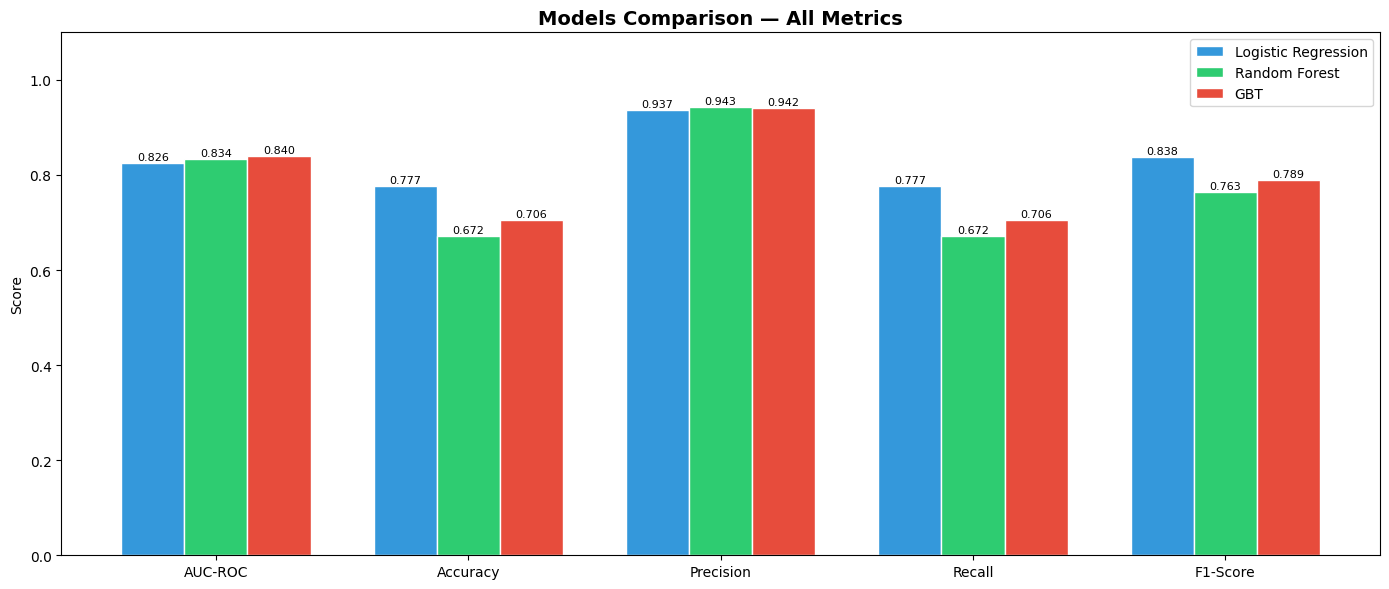

 Comparison chart saved!


In [8]:
print("=" * 60)
print(" MODELS COMPARISON")
print("=" * 60)

results_df = pd.DataFrame(all_results)
results_df = results_df.set_index("Model")

print("\n", results_df.to_string())

# Best model
best_model = results_df["AUC-ROC"].idxmax()
best_auc   = results_df["AUC-ROC"].max()

print(f"\n   Best Model : {best_model}")
print(f"     AUC-ROC    : {best_auc:.4f}")

# Plot comparison
metrics   = ["AUC-ROC", "Accuracy", "Precision", "Recall", "F1-Score"]
x         = range(len(metrics))
colors    = ["#3498db", "#2ecc71", "#e74c3c"]
bar_width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model_name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(
        [xi + i * bar_width for xi in x],
        vals,
        width=bar_width,
        label=model_name,
        color=colors[i],
        edgecolor="white"
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8
        )

ax.set_xticks([xi + bar_width for xi in x])
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Models Comparison — All Metrics", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS_PATH + "models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Comparison chart saved!")

## Cell 8 — Feature Importance Chart

 FEATURE IMPORTANCE — RF vs GBT


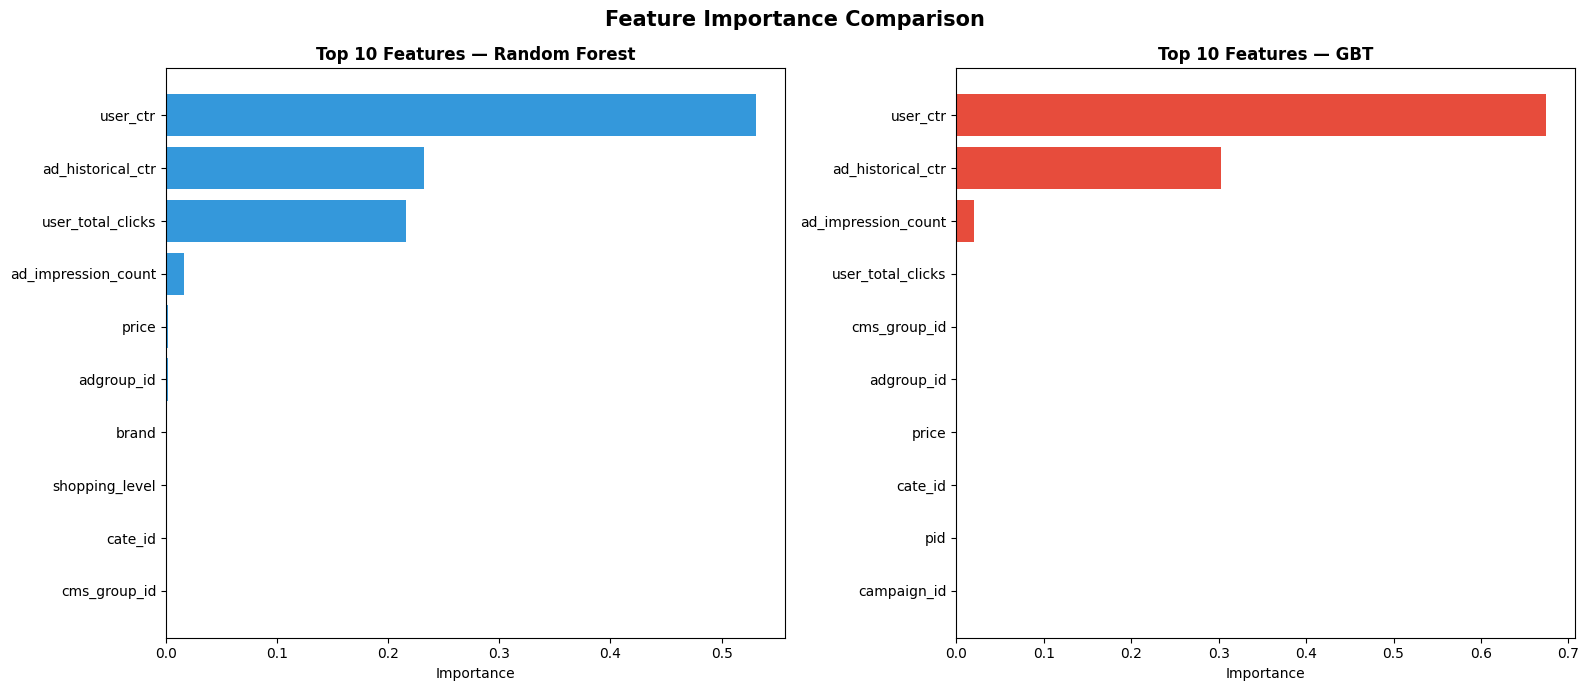

 Feature importance chart saved!


In [9]:
print(" FEATURE IMPORTANCE — RF vs GBT")
print("=" * 50)

feature_names = [
    "adgroup_id", "cate_id", "campaign_id", "brand", "price",
    "pid", "ad_historical_ctr", "ad_impression_count",
    "cms_segid", "cms_group_id", "final_gender_code",
    "age_level", "pvalue_level", "shopping_level",
    "occupation", "user_total_clicks", "user_ctr",
    "hour", "day_of_week", "is_weekend", "time_segment"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, name, color in zip(
    axes,
    [rf_model, gbt_model],
    ["Random Forest", "GBT"],
    ["#3498db", "#e74c3c"]
):
    importances = model.featureImportances.toArray()
    n           = min(len(importances), len(feature_names))
    imp_df      = pd.DataFrame({
        "Feature"   : feature_names[:n],
        "Importance": importances[:n]
    }).sort_values("Importance", ascending=False).head(10)

    ax.barh(imp_df["Feature"], imp_df["Importance"], color=color)
    ax.set_title(f"Top 10 Features — {name}", fontweight="bold")
    ax.set_xlabel("Importance")
    ax.invert_yaxis()

plt.suptitle("Feature Importance Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(CHARTS_PATH + "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Feature importance chart saved!")

## Cell 9 — Confusion Matrix

 CONFUSION MATRICES


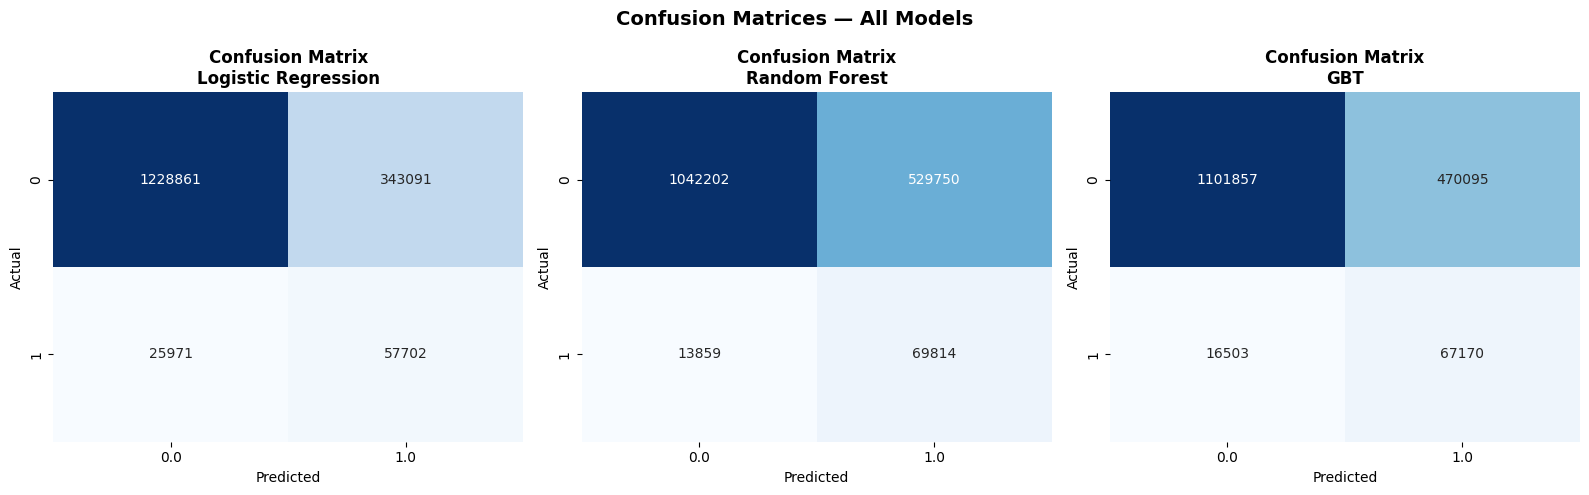

 Confusion matrices saved!


In [10]:
print(" CONFUSION MATRICES")
print("=" * 50)

def plot_confusion_matrix(predictions, model_name, ax):
    cm = predictions.groupBy("clk", "prediction") \
        .count().toPandas()

    matrix = pd.pivot_table(
        cm,
        values="count",
        index="clk",
        columns="prediction",
        fill_value=0
    )


    matrix = matrix.astype(int)

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False
    )
    ax.set_title(f"Confusion Matrix\n{model_name}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_confusion_matrix(lr_predictions,  "Logistic Regression", axes[0])
plot_confusion_matrix(rf_predictions,  "Random Forest",       axes[1])
plot_confusion_matrix(gbt_predictions, "GBT",                 axes[2])

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(CHARTS_PATH + "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Confusion matrices saved!")

## Cell 10 — Final Summary & Interpretation

In [11]:
print("=" * 60)
print(" FINAL MODELING SUMMARY")
print("=" * 60)

results_df = pd.DataFrame(all_results).set_index("Model")
best_model = results_df["AUC-ROC"].idxmax()

print("\n Results Table:")
print(results_df.to_string())

print(f"""
   Best Model: {best_model}
  ─────────────────────────────────────────
  Why {best_model} wins:
  - Highest AUC-ROC → best ability to distinguish clicks from non-clicks
  - Handles class imbalance better than Logistic Regression
  - Captures non-linear relationships in user behavior data

   Saved Models:
     → {MODEL_PATH}logistic_regression
     → {MODEL_PATH}random_forest
     → {MODEL_PATH}gbt

   Saved Charts:
     → {CHARTS_PATH}models_comparison.png
     → {CHARTS_PATH}feature_importance.png
     → {CHARTS_PATH}confusion_matrices.png

    Next Step: 04_Deployment.py (Streamlit App)
""")

spark.stop()
print(" 03_Modeling.ipynb — Complete!")

 FINAL MODELING SUMMARY

 Results Table:
                     AUC-ROC  Accuracy  Precision  Recall  F1-Score
Model                                                              
Logistic Regression   0.8257    0.7771     0.9371  0.7771    0.8375
Random Forest         0.8342    0.6717     0.9429  0.6717    0.7634
GBT                   0.8401    0.7061     0.9418  0.7061    0.7887

   Best Model: GBT
  ─────────────────────────────────────────
  Why GBT wins:
  - Highest AUC-ROC → best ability to distinguish clicks from non-clicks
  - Handles class imbalance better than Logistic Regression
  - Captures non-linear relationships in user behavior data

   Saved Models:
     → D:/Apps/ProjectBigData/models/logistic_regression
     → D:/Apps/ProjectBigData/models/random_forest
     → D:/Apps/ProjectBigData/models/gbt

   Saved Charts:
     → D:/Apps/ProjectBigData/charts/models_comparison.png
     → D:/Apps/ProjectBigData/charts/feature_importance.png
     → D:/Apps/ProjectBigData/charts/confu